In [1]:
import math
import numpy as np

# ============================================================
# 1. SCALE FACTOR
# ============================================================

def scale_factor(t):
    """
    Cosmological scale factor a(t).

    Replace this example with the desired cosmology.
    """
    return math.atan(math.pi*2*(t-1))


# ============================================================
# 2. TIME-DEPENDENT COUPLINGS
# ============================================================

def couplings(t, mass, lam=0.0):
    """
    For the canonical FLRW Hamiltonian

        H(t) =
            J1(t) * sum_j pi_j^2
          + J2(t) * sum_j phi_j^2
          + J3(t) * sum_j (phi_{j+1} - phi_j)^2
          + J4(t) * sum_j phi_j^4

    In 1+1 dimensions:

        J1 = 1 / (2 a)
        J2 = a m^2 / 2
        J3 = 1 / (2 a)
        J4 = a lambda / 4!
    """

    a = scale_factor(t)

    J1 = 1.0 / (2.0*a)
    J2 = 0.5 * a * mass**2
    J3 = 1.0 / (2.0*a)
    J4 = a * lam / 24.0

    return J1, J2, J3, J4


# ============================================================
# 3. YOUR EXISTING EVOLUTION BLOCKS
# ============================================================
#
# Keep your definitions exactly as you already have them:
#
#     Upi_wall(qc, nq, J1, tau)
#
#     Uphi_wall(qc, nq, J2, J3, J4, tau)
#
# The important point is that J1, J2, J3, J4 are now
# recomputed at each time step.
# ============================================================

def Upi_wall(qc, nq, J1, tau): # Upi_wall = sum_j Upi_j (require quantum fourier transform)
    from qiskit.circuit.library import QFTGate
    # Upi_j = exp( -i (tau J1 pi^2 / (4 delta_phi^2) ) Z_{2j} Z_{2j+1} )
    # RZZ(theta) = exp( -i (theta / 2) Z_i Z_j)
    theta = 2*tau*J1*np.pi**2 / (4*delta_phi**2)
    for j in range(L):
        qc.compose(QFTGate(2), qubits=[2*j, 2*j+1], inplace=True)
        qc.rzz(theta,2*j,2*j+1)
        qc.compose(QFTGate(2).inverse(), qubits=[2*j, 2*j+1], inplace=True)

def Uphi_wall(qc, nq, J2, J3, J4, tau): # Uphi_wall = sum_j Uphi_j
    # Uphi_j has 6 terms, Uphi_j = exp(- i tau [
    # Z_{2j}   Z_{2j+1} (J2 ( 4 phi_max^2 / 9) + J3 (4 phi_max^2 / 9) + J4 (40 phi_max^4 / 81) ) +  --> 0q between
    # Z_{2j+1} Z_{2j+2} (J3 (-4 phi_max^2 / 9) ) +   --> 0q between
    # Z_{2j+2} Z_{2j+3} (J3 ( 4 phi_max^2 / 9) ) +   --> 0q between
    # Z_{2j}   Z_{2j+2} (J3 (-8 phi_max^2 / 9) ) +   --> 1q between
    # Z_{2j+1} Z_{2j+3} (J3 (-2 phi_max^2 / 9) ) +   --> 1q between
    # Z_{2j}   Z_{2j+3} (J3 (-4 phi_max^2 / 9) ) ] ) --> 2q between
    # RZZ(theta) = exp( -i (theta / 2) Z_i Z_j)
    
    # 1. qubits next to each other
    theta1 = 2*tau*(J2*( 4*phi_max**2 / 9) + J3*(4*phi_max**2 / 9) + J4*(40*phi_max**4 / 81))
    theta2 = 2*tau*J3*(-4*phi_max**2 / 9)
    theta3 = 2*tau*J3*( 4*phi_max**2 / 9)
    def theta_even_odd(j):
        theta = 0
        if j%2==0:
            theta += theta1
        else:
            theta += theta2
        if j%2==0 and j>=2:
            theta += theta3
        return theta
    for j in range(0, nq-1, 2):
        qc.rzz(theta_even_odd(j), j, j+1)
    for j in range(1, nq-1, 2):
        qc.rzz(theta_even_odd(j), j, j+1)
    
    # 2. qubits with 1 site between them
    theta_even = 2*tau*J3*(-8)*phi_max**2 / 9
    theta_odd  = 2*tau*J3*(-2)*phi_max**2 / 9
    def theta_even_odd(j):
        if j%2==0:
            return theta_even
        else:
            return theta_odd
    for j in range(0,nq-2,3):
        qc.rzz(theta_even_odd(j), j, j+2)
    for j in range(1,nq-2,3):
        qc.rzz(theta_even_odd(j), j, j+2)
    for j in range(2,nq-2,3):
        qc.rzz(theta_even_odd(j), j, j+2)
    
    # 3. qubits with 2 sites between them
    theta = 2*tau*J3*(-4)*phi_max**2 / 9
    for j in range(0, nq-3, 4):
        qc.rzz(theta, j, j+3)
    for j in range(2, nq-3, 4):
        qc.rzz(theta, j, j+3)

    
# ============================================================
# 4. FIRST-ORDER TIME-DEPENDENT TROTTER STEP
# ============================================================

def trotter_step_1st(qc, nq, t, dt, mass, lam=0.0):
    """
    One first-order Trotter step for the time-dependent H(t).

    Midpoint prescription:

        H_n = H(t + dt/2)

    and

        U_n ~ Upi(dt) Uphi(dt)

    The ordering can also be reversed, but it must be used
    consistently.
    """

    # Evaluate time-dependent Hamiltonian at midpoint
    t_mid = t + 0.5*dt

    J1, J2, J3, J4 = couplings(
        t_mid,
        mass=mass,
        lam=lam
    )

    # Momentum evolution
    Upi_wall(
        qc,
        nq=nq,
        J1=J1,
        tau=dt
    )

    # Field / potential / gradient evolution
    Uphi_wall(
        qc,
        nq=nq,
        J2=J2,
        J3=J3,
        J4=J4,
        tau=dt
    )


# ============================================================
# 5. SECOND-ORDER TIME-DEPENDENT TROTTER STEP
# ============================================================

def trotter_step_2nd(qc, nq, t, dt, mass, lam=0.0):
    """
    One second-order (Strang) Trotter step:

        U_n ~
            Upi(dt/2)
            Uphi(dt)
            Upi(dt/2)

    with all couplings evaluated at the temporal midpoint

        t_mid = t + dt/2.
    """

    t_mid = t + 0.5*dt

    J1, J2, J3, J4 = couplings(
        t_mid,
        mass=mass,
        lam=lam
    )

    # ----------------------------------------
    # Half field evolution
    # ----------------------------------------

    Upi_wall(
        qc,
        nq=nq,
        J1=J1,
        tau=0.5*dt
    )

    # ----------------------------------------
    # Full momentum evolution
    # ----------------------------------------

    
    Uphi_wall(
        qc,
        nq=nq,
        J2=J2,
        J3=J3,
        J4=J4,
        tau=dt
    )

    # ----------------------------------------
    # Half field evolution
    # ----------------------------------------

    Upi_wall(
        qc,
        nq=nq,
        J1=J1,
        tau=0.5*dt
    )


# ============================================================
# 6. FULL TIME EVOLUTION
# ============================================================

def time_evolve(
    qc,
    nq,
    t_initial,
    t_final,
    n_steps,
    mass,
    lam=0.0,
    trotter_order=1
):
    """
    Build the complete time-dependent Trotter circuit

        U(t_final, t_initial)
          = T exp[-i integral H(t) dt]

    using either first- or second-order Trotterization.
    """

    dt = (t_final - t_initial) / n_steps

    for n in range(n_steps):

        t_n = t_initial + n*dt

        if trotter_order == 1:

            trotter_step_1st(
                qc,
                nq=nq,
                t=t_n,
                dt=dt,
                mass=mass,
                lam=lam
            )

        elif trotter_order == 2:

            trotter_step_2nd(
                qc,
                nq=nq,
                t=t_n,
                dt=dt,
                mass=mass,
                lam=lam
            )

        else:
            raise ValueError(
                "trotter_order must be 1 or 2"
            )

    return qc

In [2]:
# parameters
L         = 5
nq        = 2*L
ini       = '0'*nq
t_final   = 2
n_steps   = 10
mass      = 0.5
phi_max   = 1.5
delta_phi = (2*phi_max)/(2**nq - 1)

# classical simulator
from qiskit import *
from qiskit_aer.backends.aer_simulator import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSamplerV2

backend = AerSimulator(method="matrix_product_state",matrix_product_state_truncation_threshold=1e-8,)
sampler = AerSamplerV2.from_backend(backend,options={"run_options": {"shots": 1e5},},) 

In [3]:
# perform quantum state evolution using quantum circuits and MPS
MPS_evolution_data = {Ntrotter:{} for Ntrotter in range(1,n_steps+1)}
MPS_evolution_data[0] = {ini:1} # initial state (time 0)

for Ntrotter in range(1,n_steps+1):
    print('Trotter step ', Ntrotter)
    qc = QuantumCircuit(nq)
    qc.initialize(ini)
    time_evolve(
        qc,
        nq,
        0,
        t_final,
        n_steps,
        mass
    )
    qc.measure_active()

    # this part implements the layout and decomposes the gates we used to define the quantum circuit in native gates of the machine
    layout = [q for q in range(nq)] # maps qubit q of the quantum circuit to the machine qubit number q (not useful here since it is not a real machine)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3, initial_layout=layout)
    isa_qc = pm.run(qc) # this is now a quantum circuit that we can run in a machine (isa = instruction set architecture)

    # run the Sampler experiment
    job = sampler.run([isa_qc])

    # get counts from the experiment, invert strings (https://quantum.cloud.ibm.com/docs/en/guides/bit-ordering)
    temp   = job.result()[0].data
    counts = temp.meas.get_counts()
    counts = {x[::-1]:counts[x] for x in counts}
    
    MPS_evolution_data[Ntrotter] = counts

Trotter step  1
Trotter step  2
Trotter step  3
Trotter step  4
Trotter step  5
Trotter step  6
Trotter step  7
Trotter step  8
Trotter step  9
Trotter step  10


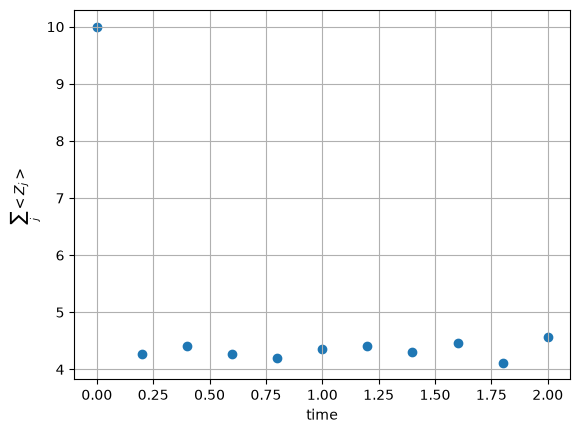

In [6]:
# simple plot: total magnetization, i.e. \sum_j \sigma_j^z

import matplotlib.pyplot as plt

def TotalZ(counts): # counts is a dictionary consisting of binary strings (keys) and the frequency that they were observed (values)
    Nshots = sum([counts[binary] for binary in counts]) # total number of experiments
    temp = 0
    for binary in counts:
        freq = counts[binary]
        for q in binary:
            temp += freq*(1-2*int(q)) # 0 = spin up (+1), 1 = spin down (-1)
    return temp/Nshots
    
evolution_total_magnetization = [TotalZ(MPS_evolution_data[Ntrotter]) for Ntrotter in range(n_steps+1)]
time = [Ntrotter*(t_final/n_steps) for Ntrotter in range(n_steps+1)]
plt.scatter(time,evolution_total_magnetization)
plt.xlabel('time')
plt.ylabel('$\sum_j <Z_j>$')
plt.grid(True)
plt.show()